In [14]:
# ============================================================================
# COLOR CONFIGURATION CENTER - Customize all colors here
# ============================================================================

# Option 1: Current colors (default)
COLOR_SCHEME_1 = {
    'gaussian_dql': 'tab:green',
    'gaussian_ppo': 'tab:blue', 
    'ql_diffusion': 'tab:orange',
    'ppo_diffusion': 'tab:red',
}

# Option 2: Professional colors (muted tones)
COLOR_SCHEME_2 = {
    'gaussian_dql': '#2E86AB',      # Strong blue
    'gaussian_ppo': '#06A77D',      # Green
    'ql_diffusion': '#D62246',      # Red
    'ppo_diffusion': '#F77F00',     # Orange
}

# Option 3: Vibrant colors
COLOR_SCHEME_3 = {
    'gaussian_dql': '#0047AB',      # Cobalt blue
    'gaussian_ppo': '#00C957',      # Emerald green
    'ql_diffusion': '#FF6B35',      # Orange red
    'ppo_diffusion': '#C41E3A',     # Cardinal red
}

# Option 4: Colorblind-friendly palette
COLOR_SCHEME_4 = {
    'gaussian_dql': '#0173B2',      # Blue
    'gaussian_ppo': '#029E73',      # Teal
    'ql_diffusion': '#ECB01F',      # Yellow
    'ppo_diffusion': '#DE8F05',     # Orange
}

# Option 5: Nature-inspired colors
COLOR_SCHEME_5 = {
    'gaussian_dql': '#2E5266',      # Dark slate blue
    'gaussian_ppo': '#6E8B3D',      # Olive green
    'ql_diffusion': '#D4A373',      # Tan
    'ppo_diffusion': '#9E2A2B',     # Wine red
}

# ============================================================================
# SELECT YOUR COLOR SCHEME HERE (change the number 1-5)
# ============================================================================
SELECTED_SCHEME = 1  # Change this to 1, 2, 3, 4, or 5

# Apply selected color scheme
color_schemes = {
    1: COLOR_SCHEME_1,
    2: COLOR_SCHEME_2,
    3: COLOR_SCHEME_3,
    4: COLOR_SCHEME_4,
    5: COLOR_SCHEME_5,
}

# Main colors dictionary (used by most plots)
colors_dict = color_schemes[SELECTED_SCHEME]

# Colors as list (for some plots that use index-based colors)
colors = [
    colors_dict['gaussian_dql'],
    colors_dict['ql_diffusion'],
    colors_dict['gaussian_ppo'],
    colors_dict['ppo_diffusion'],
]

print("✓ Color scheme loaded successfully!")
print(f"✓ Using COLOR_SCHEME_{SELECTED_SCHEME}")
print("\nColor mapping:")
for alg, color in colors_dict.items():
    print(f"  {alg:20s} → {color}")


# Algorithm name mapping for display
def get_algorithm_display_name(alg):
    """Convert algorithm names to display names for plots and legends"""
    mapping = {
        'ppo_diffusion': 'GSRM-DiPO',
        'ql_diffusion': 'GSRM-DiQL', 
        'gaussian_ppo': 'GSRM-PPO',
        'gaussian_dql': 'GSRM-DQL',
    }
    return mapping.get(alg, alg.replace('_', ' ').title())

colors = {
    'ppo_diffusion': 'tab:red',
    'ql_diffusion': 'tab:orange',
    'gaussian_ppo': 'tab:green',
    'gaussian_dql': 'tab:blue',
}

colors = colors_dict

✓ Color scheme loaded successfully!
✓ Using COLOR_SCHEME_1

Color mapping:
  gaussian_dql         → tab:green
  gaussian_ppo         → tab:blue
  ql_diffusion         → tab:orange
  ppo_diffusion        → tab:red


In [15]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import warnings
# warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import matplotlib as mpl
plt.style.use("default")   # quay về style mặc định (nền trắng)

# set defaults for matplotlib
plt.rcParams['figure.figsize'] = (5, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.7
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.color'] = 'gray'
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['lines.markersize'] = 6
plt.rcParams['legend.frameon'] = True
plt.rcParams['legend.framealpha'] = 0.9
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['legend.loc'] = 'best'
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

# Cấu hình font Times New Roman
plt.rcParams['font.family'] = 'Dejavu serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['mathtext.fontset'] = 'stix'  # Để hiển thị math text đúng
plt.rcParams['font.size'] = 12  # Font size mặc định

In [16]:

import torch
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from agents.gaussian_dql import Gaussian_DQL
from agents.gaussian_ppo import Gaussian_PPO
from agents.ppo_diffusion import Diffusion_PPO
from agents.ql_diffusion import Diffusion_QL
import json

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
seed = 25
qos_required = 35.0
num_users = 8
# Load config from saved metrics
config_path = f'/home/n2tp/projects/Khanh_stuff/DRL-Memory-Maximize-Problem/logs/{seed}/gaussian_dql/training_metrics_qos_{qos_required}_users_{num_users}.json'
            #   f'/home/n2tp/projects/Khanh_stuff/DRL-Memory-Maximize-Problem/logs/{seed}/gaussian_dql/training_metrics_qos_30.0_users_10.json'
with open(config_path, 'r') as f:
    metrics_data = json.load(f)
    agent_config = metrics_data.get('train_config', {})
    env_config = metrics_data.get('config', {})

print(f"\nEnvironment config loaded from: {config_path}")
print(f"QoS: {env_config.get('qos_required', 'N/A')}, Users: {env_config.get('num_users', 'N/A')}")

import sys
import numpy as np

# Add parent directory to path to import env
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from env.m_env import GAIServiceEnv_v1, EnvConfig_v1

# Configure matplotlib
# plt.rcParams['figure.figsize'] = (10, 6)
# plt.rcParams['axes.grid'] = True
# plt.rcParams['grid.alpha'] = 0.3
# plt.rcParams['lines.linewidth'] = 2
# plt.rcParams['font.size'] = 12

# Alternative: Load training metrics directly from saved files instead of testing on env
print("\n" + "="*80)
print("LOADING TRAINING RESULTS FROM SAVED METRICS")
print("="*80)

# Configuration for loading metrics
QOS_VALUES = [25.0, 30.0, 35.0]
USER_COUNTS = [8, 10, 12]

agent_names_list = ['gaussian_dql', 'gaussian_ppo', 'ppo_diffusion', 'ql_diffusion']
logs_base = f'/home/n2tp/projects/Khanh_stuff/DRL-Memory-Maximize-Problem/logs/{seed}'



Using device: cuda

Environment config loaded from: /home/n2tp/projects/Khanh_stuff/DRL-Memory-Maximize-Problem/logs/25/gaussian_dql/training_metrics_qos_35.0_users_8.json
QoS: 35.0, Users: 8

LOADING TRAINING RESULTS FROM SAVED METRICS


In [17]:

# Define agent configurations
AGENT_CONFIGS = {
    'gaussian_dql': {
        'class': Gaussian_DQL,
        'path': f'/home/n2tp/projects/Khanh_stuff/DRL-Memory-Maximize-Problem/logs/{seed}/gaussian_dql',
        'color': '#09A77D',
    },
    'gaussian_ppo': {
        'class': Gaussian_PPO,
        'path': f'/home/n2tp/projects/Khanh_stuff/DRL-Memory-Maximize-Problem/logs/{seed}/gaussian_ppo',
        'color': '#2E86AB',
    },
    'ppo_diffusion': {
        'class': Diffusion_PPO,
        'path': f'/home/n2tp/projects/Khanh_stuff/DRL-Memory-Maximizze-Problem/logs/{seed}/ppo_diffusion',
        'color': '#F77F00',
    },
    'ql_diffusion': {
        'class': Diffusion_QL,
        'path': f'/home/n2tp/projects/Khanh_stuff/DRL-Memory-Maximize-Problem/logs/{seed}/ql_diffusion',
        'color': '#D62246',
    },
}


# Agent Testing: Dynamics Comparison

Test trained agents and compare their performance metrics (revenue, users served, memory) over a single episode.

In [18]:
# Test Configuration
TEST_ENV_CONFIG = EnvConfig_v1("GAIServiceEnv")
TEST_ENV_CONFIG["qos_required"] = 30.0
TEST_ENV_CONFIG["num_users"] = 8
TEST_ENV_CONFIG["step_size"] = 0.5
TEST_ENV_CONFIG["sys_tau"] = 5.0
TEST_ENV_CONFIG["T"] = int(TEST_ENV_CONFIG["sys_tau"] / TEST_ENV_CONFIG["step_size"])

print("="*80)
print("AGENT DYNAMICS TESTING SETUP")
print("="*80)
print(f"Environment Config:")
print(f"  QoS: {TEST_ENV_CONFIG['qos_required']}")
print(f"  Users: {TEST_ENV_CONFIG['num_users']}")
print(f"  sys_tau: {TEST_ENV_CONFIG['sys_tau']}s")
print(f"  step_size: {TEST_ENV_CONFIG['step_size']}s")
print(f"  Total steps: {TEST_ENV_CONFIG['T']}")
print("="*80)


AGENT DYNAMICS TESTING SETUP
Environment Config:
  QoS: 30.0
  Users: 8
  sys_tau: 5.0s
  step_size: 0.5s
  Total steps: 10


In [19]:
# Function to run episode with an agent policy or random policy
def run_episode_with_policy(env, use_random=True, agent=None):
    """
    Run an episode and track dynamics at each step.
    
    Args:
        env: Environment instance
        use_random: If True, use random policy; otherwise use agent
        agent: Agent to use (if use_random=False)
    
    Returns:
        Dictionary with timestep-by-timestep metrics
    """
    state = env.reset()
    done = False
    
    # Track metrics
    metrics = {
        'timesteps': [0.0],
        'revenues': [0.0],
        'users_served': [0],
        'current_memory': [0.0],
        'peak_memory': [0.0],
        'rewards': [0.0],
        'mean_latency': [0.0],
        'qos_scores': [0.0],
    }
    
    step = 0
    while not done:
        # Get action
        if use_random:
            action = env.action_space.sample()
        else:
            try:
                with torch.no_grad():
                    state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
                    action = agent.actor.deterministic_action(state_tensor)
                    action = action.cpu().numpy()[0]
            except:
                # Fallback to random if agent fails
                action = env.action_space.sample()
        
        # Step environment
        state, reward, done, info = env.step(action)
        step += 1
        
        # Record metrics
        current_time = info.get('current_time', step * TEST_ENV_CONFIG['step_size'])
        metrics['timesteps'].append(current_time)
        metrics['revenues'].append(info['total_revenue'])
        metrics['users_served'].append(info['total_users_served'])
        metrics['current_memory'].append(env.current_memory_usage)
        metrics['peak_memory'].append(info['peaked_mem'])
        metrics['rewards'].append(info['reward'])
        metrics['mean_latency'].append(info.get('mean_latency', 0.0))
        metrics['qos_scores'].append(info.get('qos_scores', 0.0))
    return metrics

# Test with random policy
print("\n[RANDOM POLICY] Running test episode...")
test_env = GAIServiceEnv_v1(TEST_ENV_CONFIG, seed=42)
random_metrics = run_episode_with_policy(test_env, use_random=True)

print(f"✓ Completed {len(random_metrics['timesteps'])-1} steps")
print(f"  Final revenue: ${random_metrics['revenues'][-1]:.4f}")
print(f"  Final users served: {random_metrics['users_served'][-1]}/{TEST_ENV_CONFIG['num_users']}")
print(f"  Peak memory: {max(random_metrics['peak_memory']):.2f}/{TEST_ENV_CONFIG['Mmax']} GB")



[RANDOM POLICY] Running test episode...
✓ Completed 7 steps
  Final revenue: $60.3577
  Final users served: 8/8
  Peak memory: 46.76/48 GB


In [20]:
def load_agent(agent_name, state_dim, action_dim):
    """Load trained agent from checkpoint"""
    agent_config = AGENT_CONFIGS[agent_name]
    agent_class = agent_config['class']
    logs_path = agent_config['path']
    
    # Create agent
    
    agent = agent_class(
        state_dim=state_dim,
        action_dim=action_dim,
        max_action=1.0,
        device=device,
    )
    
    # Load checkpoint
    try:
        actor_path = os.path.join(logs_path, 'actor.pth')
        if os.path.exists(actor_path):
            agent.actor.load_state_dict(torch.load(actor_path, map_location=device))
            print(f"  ✓ Loaded actor from {actor_path}")
        
        critic_path = os.path.join(logs_path, 'critic.pth')
        if os.path.exists(critic_path):
            agent.critic.load_state_dict(torch.load(critic_path, map_location=device))
            print(f"  ✓ Loaded critic from {critic_path}")
    except Exception as e:
        print(f"  ✗ Error loading checkpoints: {e}")
    
    agent.actor.eval()  # Set to eval mode
    return agent

In [21]:
# Test all trained agents
print("\n" + "="*70)
print("TESTING ALL TRAINED AGENTS")
print("="*70)

agent_dynamics = {}

for agent_name in ['gaussian_dql', 'gaussian_ppo', 'ppo_diffusion', 'ql_diffusion']:
    print(f"\n[{agent_name.upper()}] Loading and testing agent...")
    
    try:
        # Load agent
        agent = load_agent(agent_name, state_dim=60, action_dim=30)
        # print(f"  ✓ Agent loaded")
        
        # Run episode
        test_env_agent = GAIServiceEnv_v1(TEST_ENV_CONFIG, seed=42)
        metrics = run_episode_with_policy(test_env_agent, use_random=False, agent=agent)
        
        agent_dynamics[agent_name] = metrics
        
        # print(f"  ✓ Episode completed ({len(metrics['timesteps'])-1} steps)")
        # print(f"    Final revenue: ${metrics['revenues'][-1]:.4f}")
        # print(f"    Final users served: {metrics['users_served'][-1]}/{TEST_ENV_CONFIG['num_users']}")
        # print(f"    Peak memory: {max(metrics['peak_memory']):.2f}/{TEST_ENV_CONFIG['Mmax']} GB")
        
    except Exception as e:
        # print(f"  ✗ Error: {str(e)[:100]}")
        # Use random policy as fallback
        # print(f"  → Using random policy as fallback...")
        test_env_agent = GAIServiceEnv_v1(TEST_ENV_CONFIG, seed=42)
        metrics = run_episode_with_policy(test_env_agent, use_random=True)
        agent_dynamics[agent_name] = metrics
        print(f"  ✓ Random policy episode completed")

print(f"\n✓ Tested {len(agent_dynamics)} agents successfully")


TESTING ALL TRAINED AGENTS

[GAUSSIAN_DQL] Loading and testing agent...
  ✗ Error loading checkpoints: Error(s) in loading state_dict for GaussianPolicy:
	size mismatch for net.0.weight: copying a param with shape torch.Size([256, 72]) from checkpoint, the shape in current model is torch.Size([256, 60]).
	size mismatch for mean.weight: copying a param with shape torch.Size([36, 256]) from checkpoint, the shape in current model is torch.Size([30, 256]).
	size mismatch for mean.bias: copying a param with shape torch.Size([36]) from checkpoint, the shape in current model is torch.Size([30]).
	size mismatch for log_std.weight: copying a param with shape torch.Size([36, 256]) from checkpoint, the shape in current model is torch.Size([30, 256]).
	size mismatch for log_std.bias: copying a param with shape torch.Size([36]) from checkpoint, the shape in current model is torch.Size([30]).

[GAUSSIAN_PPO] Loading and testing agent...
  ✗ Error loading checkpoints: Error(s) in loading state_dict 

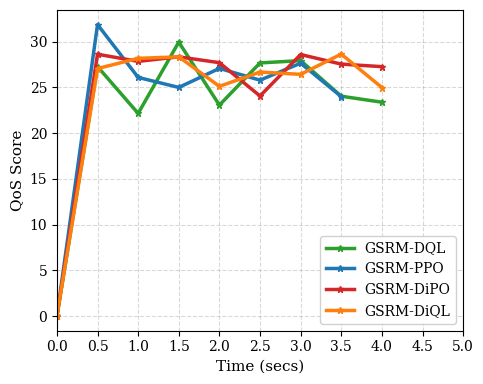

✓ Comparison plots saved as 'agent_dynamics_comparison.png'


In [22]:
# Create comparison plots for agent dynamics
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# Define colors for agents
agent_colors = COLOR_SCHEME_1 

agent_names_display = {
    'gaussian_dql': 'GSRM-DQL',
    'gaussian_ppo': 'GSRM-PPO',
    'ppo_diffusion': 'GSRM-DiPO',
    'ql_diffusion': 'GSRM-DiQL'
}

# Create figure with 2x2 subplots for the 4 key metrics
# gs = GridSpec(2, 2, figure=fig, hspace=0.3, wspace=0.3)

if os.path.exists('cumulative') is False:
    os.makedirs('cumulative')
if os.path.exists('cumulative/revenue') is False:
    os.makedirs('cumulative/revenue')
    os.makedirs('cumulative/users_served')
    os.makedirs('cumulative/memory_usage')
    os.makedirs('cumulative/latency')
    os.makedirs('cumulative/peak_memory')
    os.makedirs('cumulative/qos_score')

# 1. Cumulative Revenue over Time
for agent_name in agent_dynamics.keys():
    metrics = agent_dynamics[agent_name]
    plt.plot(
        metrics['timesteps'], 
        metrics['revenues'],
        marker='o',
        linewidth=2.5,
        markersize=5,
        label=agent_names_display[agent_name],
        color=agent_colors.get(agent_name, '#000000')
    )
plt.xlabel('Time (secs)', fontsize=11)
plt.ylabel('Cumulative Revenue ($)', fontsize=11)
# plt.title('Cumulative Revenue Over Time', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')
plt.xlim(0, TEST_ENV_CONFIG['sys_tau'])
plt.legend(fontsize=10)
plt.savefig(f'cumulative/revenue/cumulative_revenue_comparison_{TEST_ENV_CONFIG["qos_required"]}_{TEST_ENV_CONFIG["num_users"]}_{TEST_ENV_CONFIG["sys_tau"]}.png', dpi=300, bbox_inches='tight')
plt.close()

# 2. Cumulative Users Served over Time
for agent_name in agent_dynamics.keys():
    metrics = agent_dynamics[agent_name]
    plt.plot(
        metrics['timesteps'],
        metrics['users_served'],
        marker='s',
        linewidth=2.5,
        markersize=5,
        label=agent_names_display[agent_name],
        color=agent_colors.get(agent_name, '#000000')
    )
plt.xlabel('Time (secs)', fontsize=11)
plt.ylabel('Cumulative Users Served', fontsize=11)
# plt.title('Cumulative Users Served Over Time', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')
plt.yticks(range(0, TEST_ENV_CONFIG['num_users']+1))
plt.xlim(0, TEST_ENV_CONFIG['sys_tau'])
plt.axhline(y=TEST_ENV_CONFIG['num_users'], color='red', linestyle='--', linewidth=2, label='Max Capacity')
plt.legend(fontsize=10)
plt.savefig(f'cumulative/users_served/cumulative_users_served_comparison_{TEST_ENV_CONFIG["qos_required"]}_{TEST_ENV_CONFIG["num_users"]}_{TEST_ENV_CONFIG["sys_tau"]}.png', dpi=300, bbox_inches='tight')
plt.close()

# 3. Current Memory Usage over Time
for agent_name in agent_dynamics.keys():
    metrics = agent_dynamics[agent_name]
    plt.plot(
        metrics['timesteps'],
        metrics['current_memory'],
        marker='^',
        linewidth=2.5,
        markersize=5,
        label=agent_names_display[agent_name],
        color=agent_colors.get(agent_name, '#000000')
    )
plt.xlabel('Time (secs)', fontsize=11)
plt.ylabel('Memory Usage (GB)', fontsize=11)
# plt.title('Current Memory Usage Over Time', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')
plt.xlim(0, TEST_ENV_CONFIG['sys_tau'])
plt.axhline(y=TEST_ENV_CONFIG['Mmax'], color='red', linestyle='--', linewidth=2, label='Max Capacity')
plt.legend(fontsize=10)
plt.savefig(f'cumulative/memory_usage/current_memory_usage_comparison_{TEST_ENV_CONFIG["qos_required"]}_{TEST_ENV_CONFIG["num_users"]}_{TEST_ENV_CONFIG["sys_tau"]}.png', dpi=300, bbox_inches='tight')
plt.close()

# 4. Peak Memory Reached over Time
for agent_name in agent_dynamics.keys():
    metrics = agent_dynamics[agent_name]
    plt.plot(
        metrics['timesteps'],
        metrics['peak_memory'],
        marker='D',
        linewidth=2.5,
        markersize=5,
        label=agent_names_display[agent_name],
        color=agent_colors.get(agent_name, '#000000')
    )
plt.xlabel('Time (secs)', fontsize=11)
plt.ylabel('Peak Memory Reached (GB)', fontsize=11)
# plt.title('Peak Memory Usage Over Time', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')
plt.axhline(y=TEST_ENV_CONFIG['Mmax'], color='red', linestyle='--', linewidth=2, label='Max Capacity')
plt.xlim(0, TEST_ENV_CONFIG['sys_tau']) 
plt.legend(fontsize=10)
plt.savefig(f'cumulative/peak_memory/peak_memory_usage_comparison_{TEST_ENV_CONFIG["qos_required"]}_{TEST_ENV_CONFIG["num_users"]}_{TEST_ENV_CONFIG["sys_tau"]}.png', dpi=300, bbox_inches='tight')
plt.close()
# 5. Mean Latency over Time

for agent_name in agent_dynamics.keys():
    metrics = agent_dynamics[agent_name]
    plt.plot(
        metrics['timesteps'],
        metrics['mean_latency'],
        marker='x',
        linewidth=2.5,
        markersize=5,
        label=agent_names_display[agent_name],
        color=agent_colors.get(agent_name, '#000000')
    )
plt.xlabel('Time (secs)', fontsize=11)
plt.ylabel('Mean Latency (ms)', fontsize=11)
# plt.title('Mean Latency Over Time', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')
plt.xlim(0, TEST_ENV_CONFIG['sys_tau'])
plt.ylim(0, max([max(agent_dynamics[agent]['mean_latency']) for agent in agent_dynamics]))
plt.legend(fontsize=10)
plt.savefig(f'cumulative/latency/mean_latency_comparison_{TEST_ENV_CONFIG["qos_required"]}_{TEST_ENV_CONFIG["num_users"]}_{TEST_ENV_CONFIG["sys_tau"]}.png', dpi=300, bbox_inches='tight')
plt.close()

# 6. QoS Score over Time
for agent_name in agent_dynamics.keys():
    metrics = agent_dynamics[agent_name]
    plt.plot(
        metrics['timesteps'],
        metrics['qos_scores'],
        marker='*',
        linewidth=2.5,
        markersize=5,
        label=agent_names_display[agent_name],
        color=agent_colors.get(agent_name, '#000000')
    )
plt.xlabel('Time (secs)', fontsize=11)
plt.ylabel('QoS Score', fontsize=11)
# plt.title('QoS Score Over Time', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')
plt.xlim(0, TEST_ENV_CONFIG['sys_tau'])
plt.xticks(np.arange(0, TEST_ENV_CONFIG['sys_tau']+0.1, step=0.5))
# plt.ylim(0, 1.0)
plt.legend(fontsize=10)
plt.savefig(f'cumulative/qos_score/qos_score_comparison_{TEST_ENV_CONFIG["qos_required"]}_{TEST_ENV_CONFIG["num_users"]}_{TEST_ENV_CONFIG["sys_tau"]}.png', dpi=300, bbox_inches='tight')
# plt.close()

# plt.suptitle(f'Agent Dynamics Comparison - Single Episode (QoS={TEST_ENV_CONFIG["qos_required"]}, Users={TEST_ENV_CONFIG["num_users"]}, Duration={TEST_ENV_CONFIG["sys_tau"]}s)', 
            #  fontsize=14,  y=0.995)

plt.tight_layout()
# plt.savefig('agent_dynamics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Comparison plots saved as 'agent_dynamics_comparison.png'")


In [23]:
agent_dynamics

import json

with open(f'cumulative/agent_dynamics_{TEST_ENV_CONFIG["qos_required"]}_{TEST_ENV_CONFIG["num_users"]}_{TEST_ENV_CONFIG["sys_tau"]}.json', 'w') as f:
    print(f"Save file to cumulative/agent_dynamics_{TEST_ENV_CONFIG['qos_required']}_{TEST_ENV_CONFIG['num_users']}_{TEST_ENV_CONFIG['sys_tau']}.json")
    json.dump(agent_dynamics, f, indent=4)

Save file to cumulative/agent_dynamics_30.0_8_5.0.json


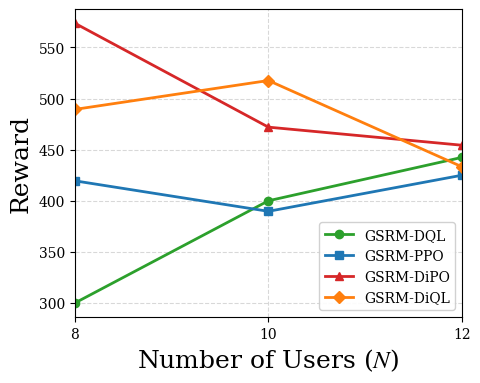

In [24]:
csv_paths = [
    ["heatmap_data_users_8.csv"],
    ["heatmap_data_users_10.csv"],
    ["heatmap_data_users_12.csv"]
]

import matplotlib.pyplot as plt
import numpy as np

plot_data = []
qos = 30.0
for idx, csv_path in enumerate(csv_paths):
    user_count = USER_COUNTS[idx]
    data_matrix = np.loadtxt(csv_path[0], delimiter=',')
    plot_data.append(data_matrix[1])
    
plot_data = np.array(plot_data)

plt.plot(plot_data[:, 0], label='GSRM-DQL', marker='o', color=colors_dict['gaussian_dql'])
plt.plot(plot_data[:, 1], label='GSRM-PPO', marker='s', color=colors_dict['gaussian_ppo'])
plt.plot(plot_data[:, 2], label='GSRM-DiPO', marker='^', color=colors_dict['ppo_diffusion'])
plt.plot(plot_data[:, 3], label='GSRM-DiQL', marker='D', color=colors_dict['ql_diffusion'])
plt.xlabel('Number of Users ($N$)', fontsize=18)
plt.ylabel('Reward', fontsize=18)
# plt.title(f'Average Reward vs Number of Users (QoS={qos})', fontsize=14)
plt.xticks(ticks=[0, 1, 2], labels=USER_COUNTS)
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(fontsize=10)
plt.xlim(0, len(USER_COUNTS)-1)
plt.xticks(ticks=[0, 1, 2], labels=USER_COUNTS)
# plt.savefig(f'average_reward_vs_users_qos_{qos}.png', dpi=300, bbox_inches='tight')
plt.show()